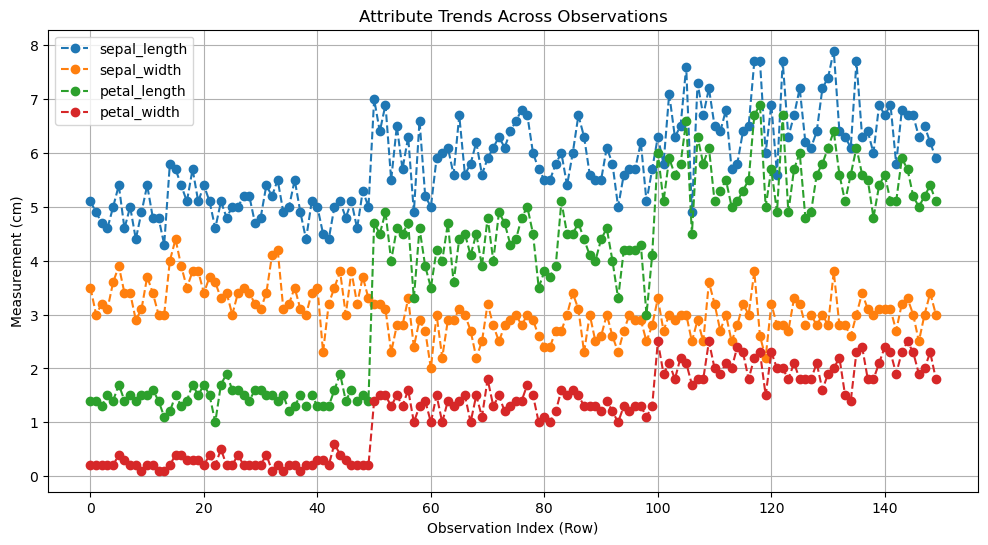

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Correct the file path 
file_path = 'temp.csv'

# Load the CSV
df = pd.read_csv(file_path)

# Plot trends
plt.figure(figsize=(12, 6))
for column in ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']:
    plt.plot(df.index, df[column], marker='o', linestyle='--', label=column)

plt.title('Attribute Trends Across Observations')
plt.xlabel('Observation Index (Row)')
plt.ylabel('Measurement (cm)')
plt.legend()
plt.grid(True)
plt.show()

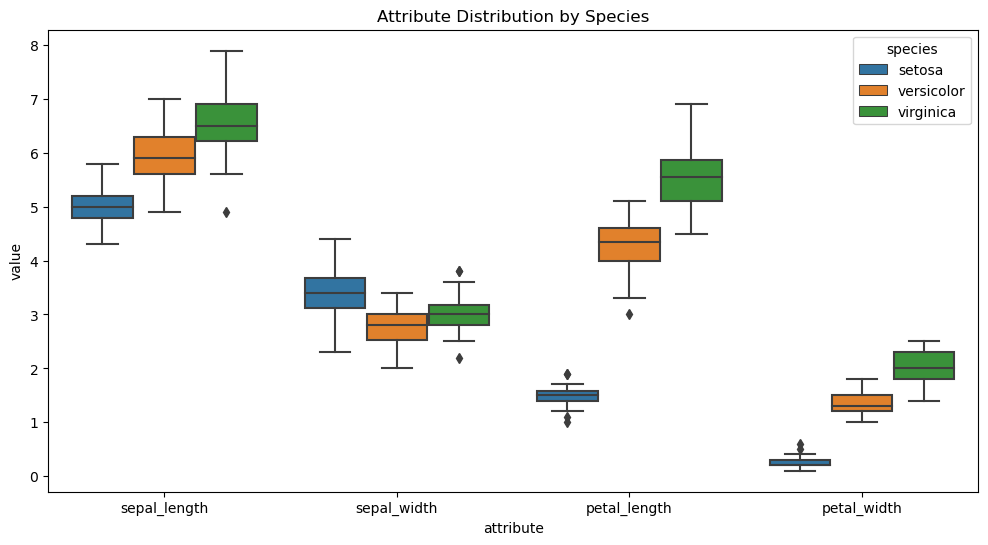

In [5]:
import seaborn as sns

# Melt data for seaborn compatibility
melted_df = pd.melt(df, id_vars='species', var_name='attribute', value_name='value')

# Plot grouped boxplots
plt.figure(figsize=(12, 6))
sns.boxplot(data=melted_df, x='attribute', y='value', hue='species')
plt.title('Attribute Distribution by Species')
plt.show()

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


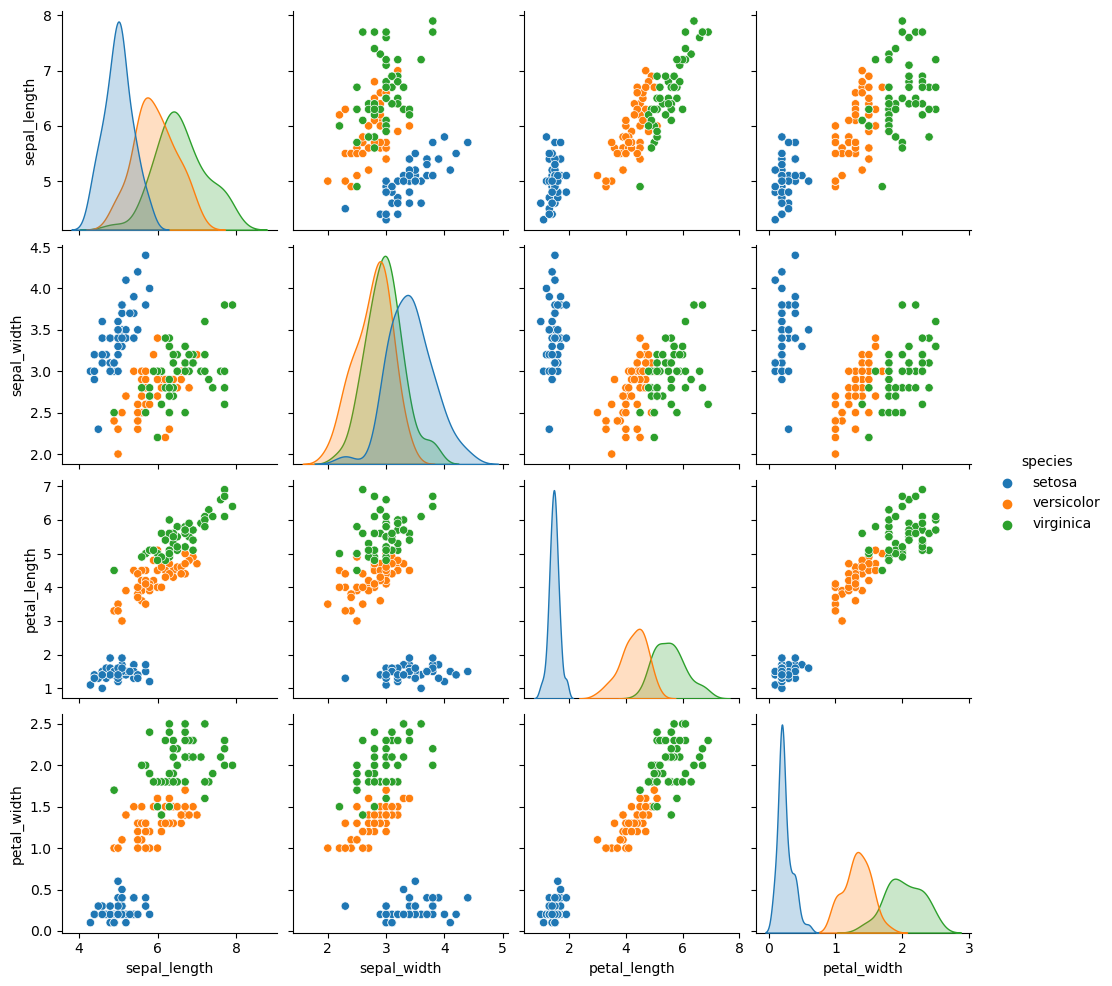

In [6]:
sns.pairplot(df, hue='species')
plt.show()

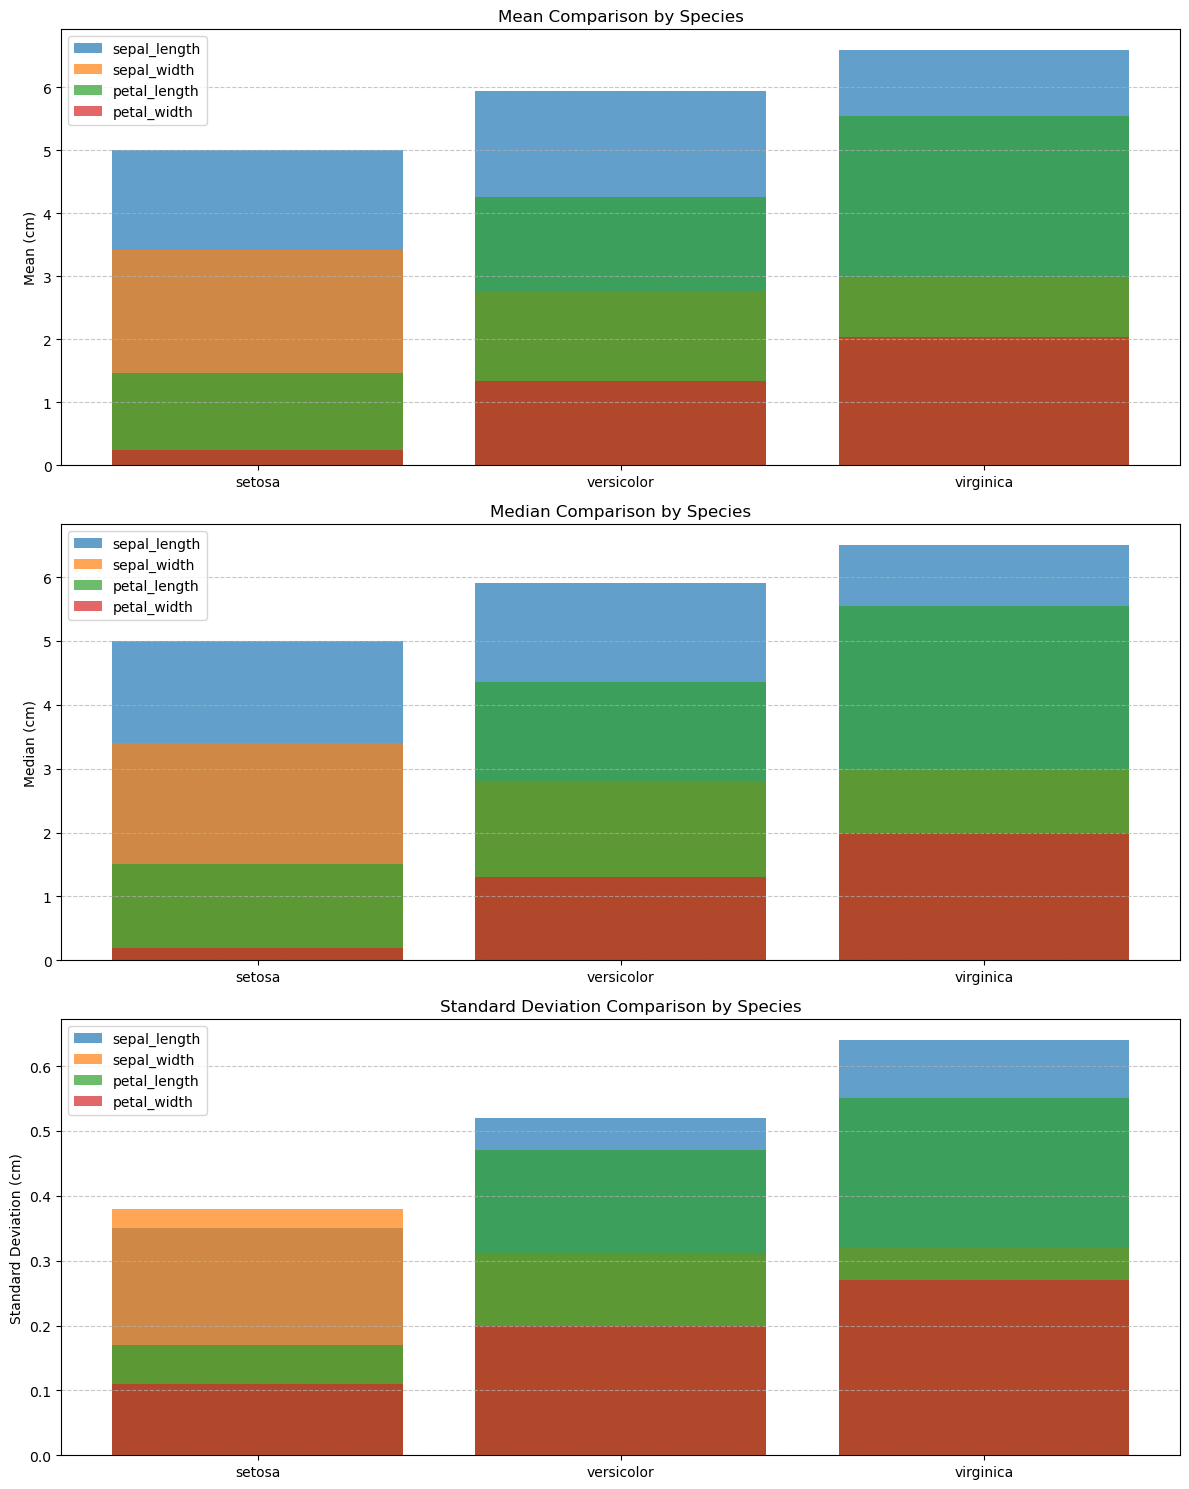

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('temp.csv')

# Group by species and calculate stats
grouped = df.groupby('species').agg(['mean', 'median', 'std']).round(2)

# Define numerical columns to analyze
numerical_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# Create subplots for mean, median, and std
fig, axes = plt.subplots(3, 1, figsize=(12, 15))

# Plot settings (4 colors for 4 numerical columns)
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Added a 4th color (red)

# 1. Mean Comparison
for i, col in enumerate(numerical_cols):
    axes[0].bar(grouped.index, grouped[col]['mean'], color=colors[i], alpha=0.7, label=col)
axes[0].set_title('Mean Comparison by Species')
axes[0].set_ylabel('Mean (cm)')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)
axes[0].legend()

# 2. Median Comparison
for i, col in enumerate(numerical_cols):
    axes[1].bar(grouped.index, grouped[col]['median'], color=colors[i], alpha=0.7, label=col)
axes[1].set_title('Median Comparison by Species')
axes[1].set_ylabel('Median (cm)')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)
axes[1].legend()

# 3. Standard Deviation Comparison
for i, col in enumerate(numerical_cols):
    axes[2].bar(grouped.index, grouped[col]['std'], color=colors[i], alpha=0.7, label=col)
axes[2].set_title('Standard Deviation Comparison by Species')
axes[2].set_ylabel('Standard Deviation (cm)')
axes[2].grid(axis='y', linestyle='--', alpha=0.7)
axes[2].legend()

plt.tight_layout()
plt.show()

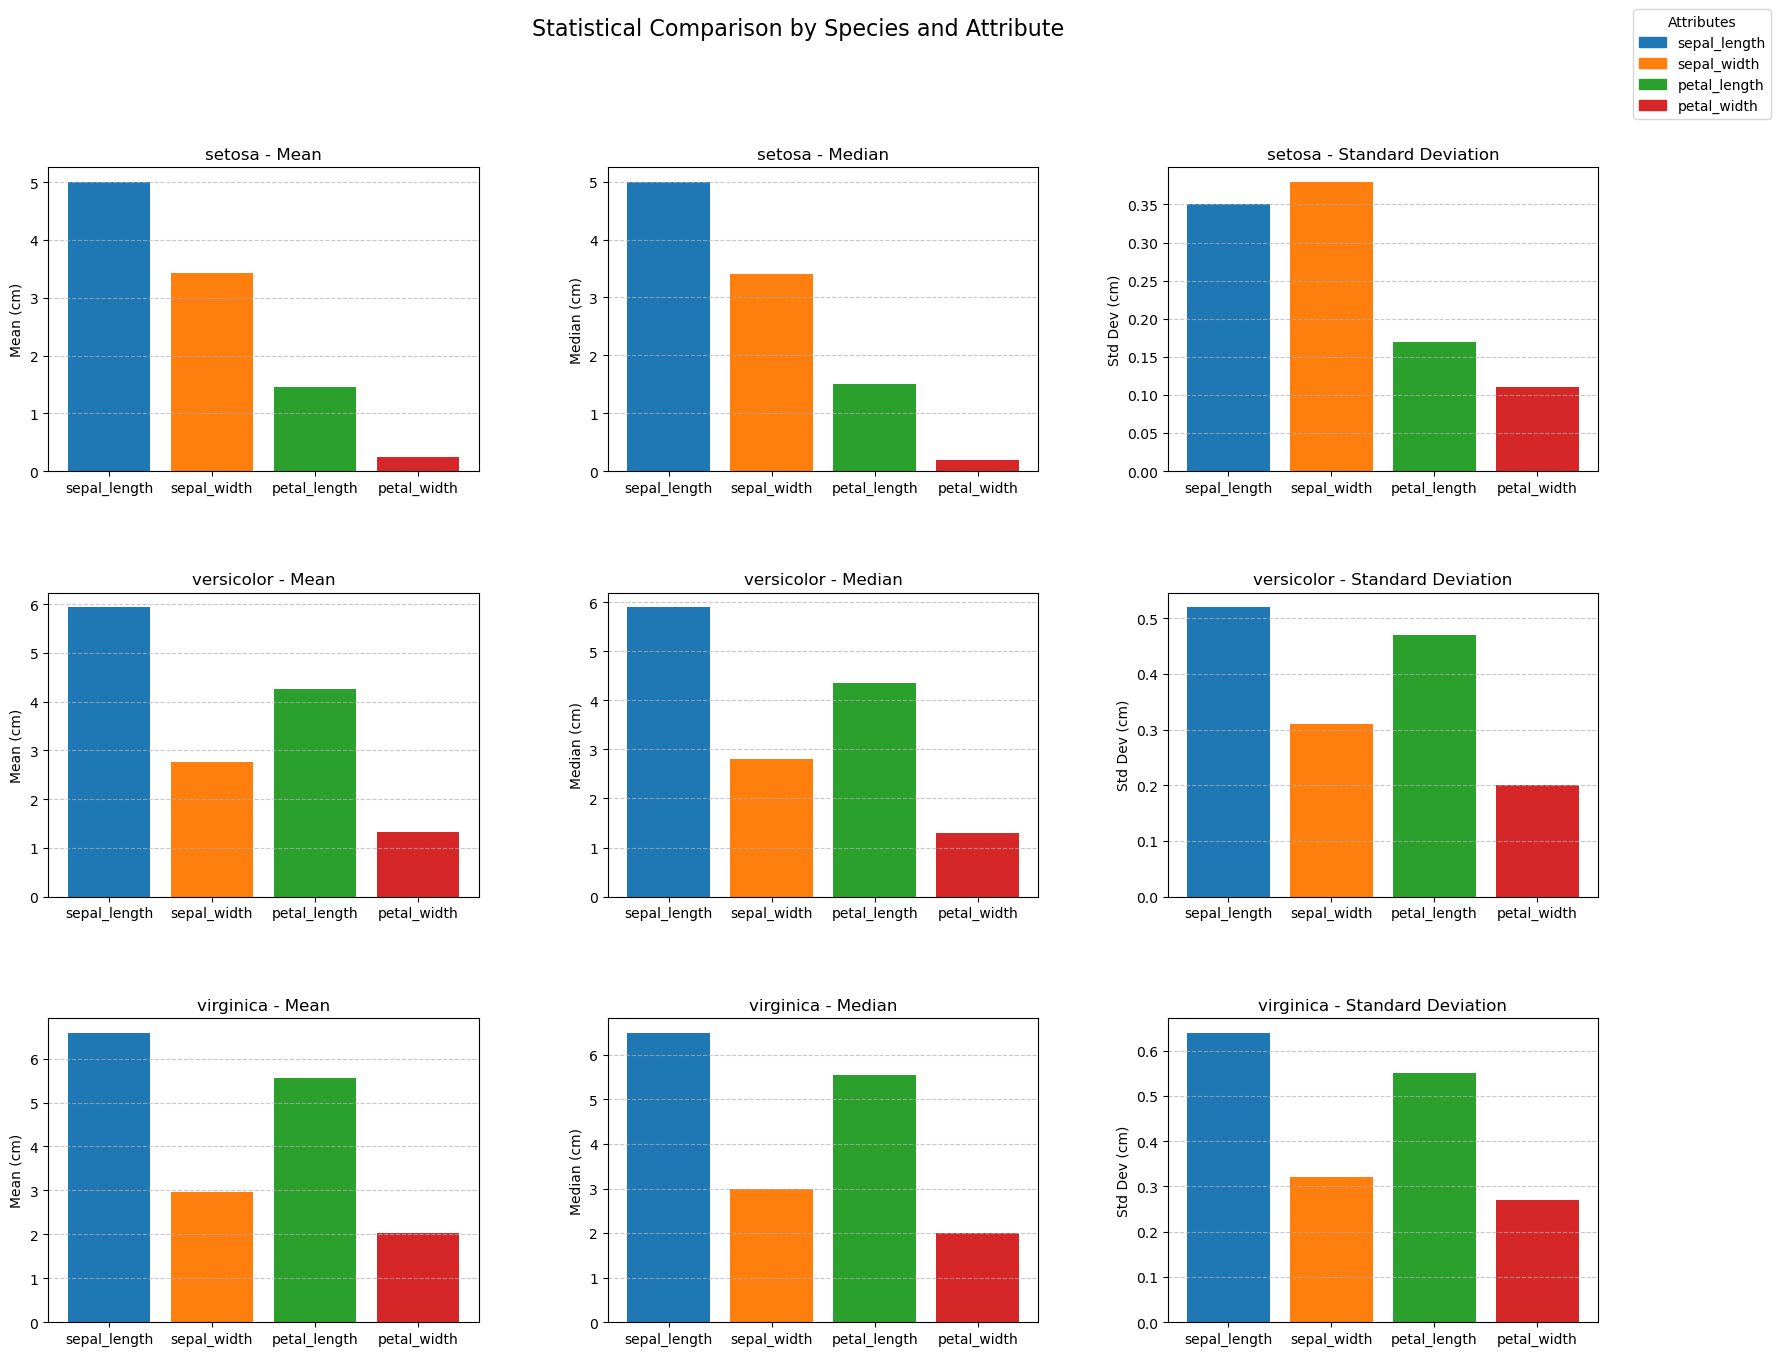

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the dataset
df = pd.read_csv('temp.csv')

# Group by species and calculate statistics
grouped = df.groupby('species').agg(['mean', 'median', 'std']).round(2)
species = grouped.index.tolist()  # ['setosa', 'versicolor', 'virginica']
numerical_cols = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

# Define colors for numerical columns
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']  # Blue, Orange, Green, Red

# Create a 3x3 grid (3 species × 3 statistics)
fig, axes = plt.subplots(3, 3, figsize=(20, 15))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Plot for each species and statistic
for row, species_name in enumerate(species):
    # Mean
    axes[row, 0].bar(numerical_cols, grouped.loc[species_name].xs('mean', level=1), color=colors)
    axes[row, 0].set_title(f'{species_name} - Mean', fontsize=12)
    axes[row, 0].set_ylabel('Mean (cm)')
    axes[row, 0].grid(axis='y', linestyle='--', alpha=0.7)
    
    # Median
    axes[row, 1].bar(numerical_cols, grouped.loc[species_name].xs('median', level=1), color=colors)
    axes[row, 1].set_title(f'{species_name} - Median', fontsize=12)
    axes[row, 1].set_ylabel('Median (cm)')
    axes[row, 1].grid(axis='y', linestyle='--', alpha=0.7)
    
    # Standard Deviation
    axes[row, 2].bar(numerical_cols, grouped.loc[species_name].xs('std', level=1), color=colors)
    axes[row, 2].set_title(f'{species_name} - Standard Deviation', fontsize=12)
    axes[row, 2].set_ylabel('Std Dev (cm)')
    axes[row, 2].grid(axis='y', linestyle='--', alpha=0.7)

# Add legend (use first subplot for legend)
handles = [plt.Rectangle((0,0),1,1, color=colors[i]) for i in range(len(numerical_cols))]
fig.legend(handles, numerical_cols, loc='upper right', bbox_to_anchor=(0.99, 0.99), title='Attributes')

plt.suptitle('Statistical Comparison by Species and Attribute', fontsize=16)
plt.show()

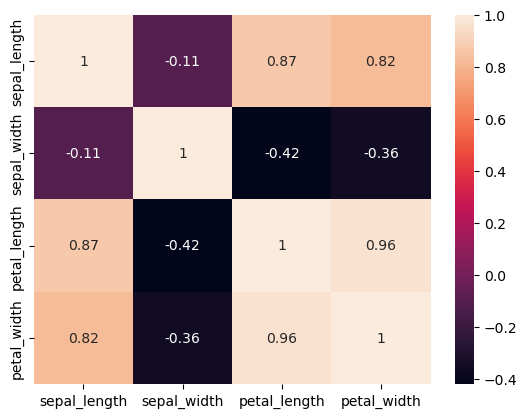

In [11]:
import seaborn as sns

# Heatmap for numerical correlations
corr_matrix = df.corr(numeric_only=True)
sns.heatmap(corr_matrix, annot=True)
plt.show()

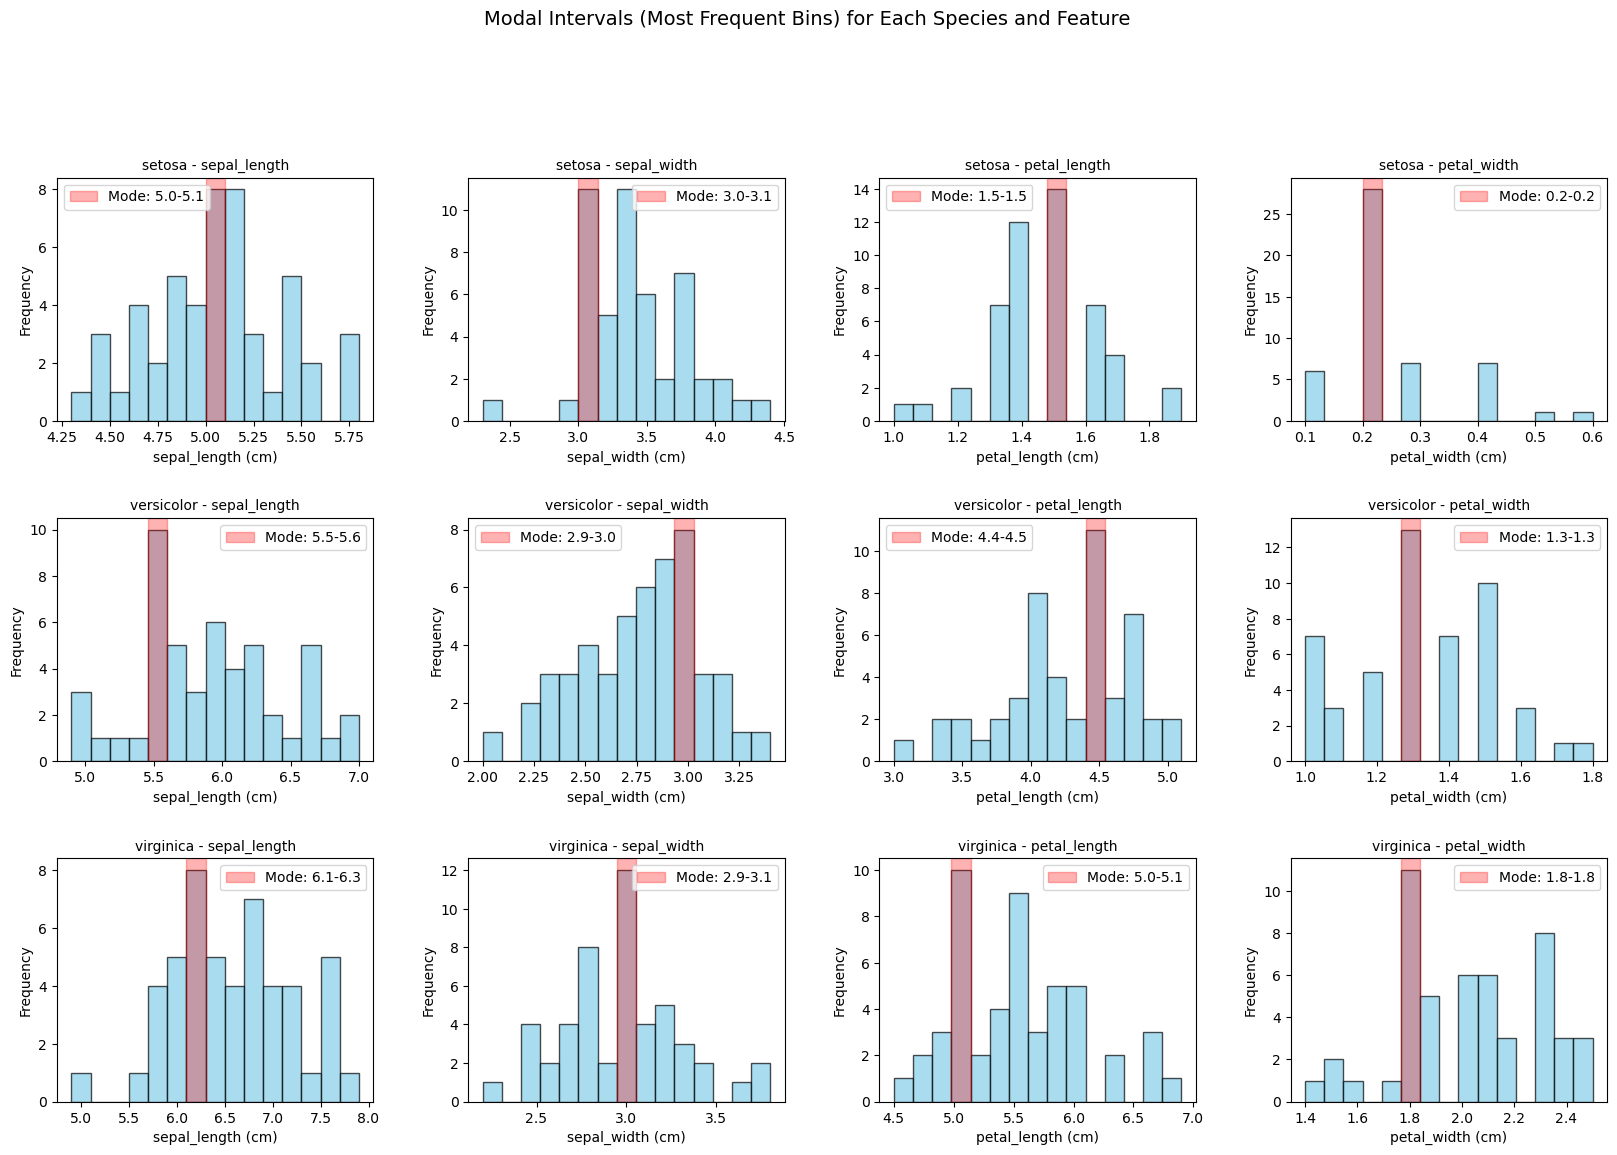

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
df = pd.read_csv('temp.csv')

# Define features and species
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
species = df['species'].unique()

# Create subplots
fig, axes = plt.subplots(3, 4, figsize=(20, 12))
plt.subplots_adjust(hspace=0.4, wspace=0.3)

# Plot histograms for each species and feature
for row, sp in enumerate(species):
    species_df = df[df['species'] == sp]
    for col, feature in enumerate(features):
        ax = axes[row, col]
        data = species_df[feature]
        
        # Calculate histogram bins and counts
        counts, bins = np.histogram(data, bins=15)
        max_bin_idx = np.argmax(counts)
        mode_lower = bins[max_bin_idx]
        mode_upper = bins[max_bin_idx + 1]
        
        # Plot histogram
        ax.hist(data, bins=15, color='skyblue', edgecolor='black', alpha=0.7)
        ax.axvspan(mode_lower, mode_upper, color='red', alpha=0.3, label=f'Mode: {mode_lower:.1f}-{mode_upper:.1f}')
        ax.set_title(f'{sp} - {feature}', fontsize=10)
        ax.set_xlabel(f'{feature} (cm)')
        ax.set_ylabel('Frequency')
        ax.legend()

plt.suptitle('Modal Intervals (Most Frequent Bins) for Each Species and Feature', fontsize=14, y=1.02)
plt.show()

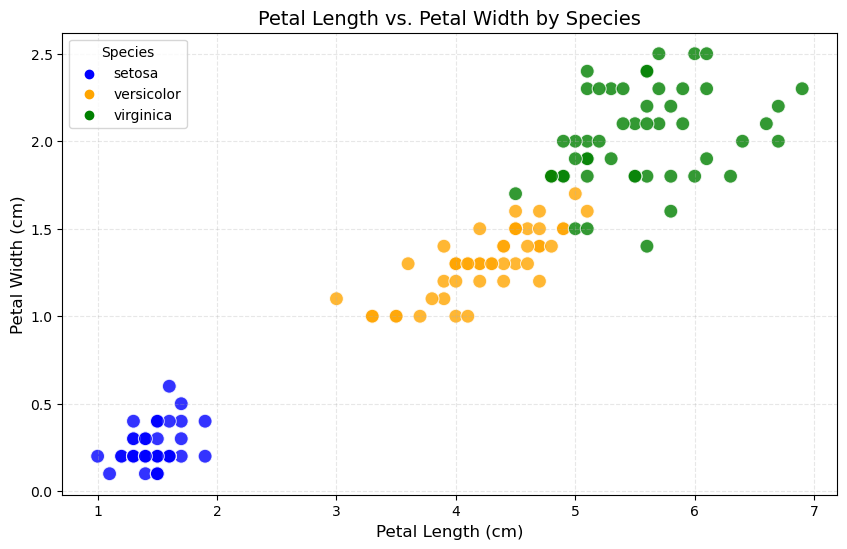

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('temp.csv')

# Create a scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='petal_length',
    y='petal_width',
    hue='species',
    palette=['blue', 'orange', 'green'],
    s=100,  # Size of points
    alpha=0.8
)

plt.title('Petal Length vs. Petal Width by Species', fontsize=14)
plt.xlabel('Petal Length (cm)', fontsize=12)
plt.ylabel('Petal Width (cm)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(title='Species')
plt.show()